In [1]:
# =========================================================
# PIPELINE TO BUILD A COMBINED DATASET FOR SELECTED YEARS / MONTHS
# =========================================================

import os
import glob
import duckdb
import pandas as pd


In [13]:

# ---------------------------------------------------------
# 1) CONFIG
# ---------------------------------------------------------
BASE_DATA_DIR = "data"   # structure expected: repo/data/2023/, repo/data/2024/, etc.

# Example inputs : choose the years and months you want to include in the combined dataset
years = [2023, 2024, 2025]
months = [1, 2, 3, 4, 5, 6]


In [8]:

# ---------------------------------------------------------
# 2) HELPER: format month as 2 digits
# ---------------------------------------------------------
def month_to_str(month):
    return f"{int(month):02d}"

# ---------------------------------------------------------
# 3) HELPER: validate inputs
# ---------------------------------------------------------
def validate_inputs(years, months):
    if not years:
        raise ValueError("years list is empty")
    if not months:
        raise ValueError("months list is empty")
    
    for y in years:
        if not isinstance(y, int):
            raise TypeError(f"Year must be int, got {y}")
    
    for m in months:
        if not isinstance(m, int):
            raise TypeError(f"Month must be int, got {m}")
        if m < 1 or m > 12:
            raise ValueError(f"Month must be between 1 and 12, got {m}")

# ---------------------------------------------------------
# 4) FIND FILES
# ---------------------------------------------------------
def get_selected_files(base_data_dir, years, months, taxi_type="yellow"):
    validate_inputs(years, months)
    
    selected_files = []
    missing_files = []
    
    for year in years:
        for month in months:
            month_str = month_to_str(month)
            expected_file = os.path.join(
                base_data_dir,
                str(year),
                f"{taxi_type}_tripdata_{year}-{month_str}.parquet"
            )
            
            if os.path.exists(expected_file):
                selected_files.append(expected_file)
            else:
                missing_files.append(expected_file)
    
    return selected_files, missing_files


In [9]:

# ---------------------------------------------------------
# 5) BUILD SUMMARY TABLE
# ---------------------------------------------------------
def build_file_summary(file_paths):
    rows = []
    
    for path in file_paths:
        filename = os.path.basename(path)
        
        # Parse year and month from filename like yellow_tripdata_2025-03.parquet
        year_month = filename.replace(".parquet", "").split("_")[-1]
        year_str, month_str = year_month.split("-")
        
        rows.append({
            "year": int(year_str),
            "month": int(month_str),
            "file": filename,
            "path": path
        })
    
    df = pd.DataFrame(rows).sort_values(["year", "month"]).reset_index(drop=True)
    return df


In [10]:

# ---------------------------------------------------------
# 6) CREATE DUCKDB VIEW
# ---------------------------------------------------------
def create_combined_view(con, file_paths, view_name="trips_selected"):
    if len(file_paths) == 0:
        raise ValueError("No files found for the selected years/months")
    
    file_list_sql = ", ".join([f"'{path}'" for path in file_paths])
    
    query = f"""
    CREATE OR REPLACE VIEW {view_name} AS
    SELECT *
    FROM read_parquet([{file_list_sql}], union_by_name=True)
    """
    
    con.execute(query)


In [11]:

# ---------------------------------------------------------
# 7) MAIN PIPELINE
# ---------------------------------------------------------
def build_combined_dataset(base_data_dir, years, months, taxi_type="yellow", view_name="trips_selected"):
    selected_files, missing_files = get_selected_files(base_data_dir, years, months, taxi_type=taxi_type)
    
    summary_df = build_file_summary(selected_files) if selected_files else pd.DataFrame()
    
    con = duckdb.connect()
    create_combined_view(con, selected_files, view_name=view_name)
    
    return {
        "con": con,
        "view_name": view_name,
        "selected_files": selected_files,
        "missing_files": missing_files,
        "summary_df": summary_df
    }


In [14]:

# ---------------------------------------------------------
# 8) RUN PIPELINE
# ---------------------------------------------------------
result = build_combined_dataset(
    base_data_dir=BASE_DATA_DIR,
    years=years,
    months=months,
    taxi_type="yellow",
    view_name="trips_yearwise"
)

con = result["con"]
view_name = result["view_name"]
summary_df = result["summary_df"]
missing_files = result["missing_files"]

print("Selected files:")
display(summary_df)

print(f"Number of selected files: {len(result['selected_files'])}")
print()

if missing_files:
    print("Missing files:")
    for f in missing_files:
        print("-", f)
    print()
else:
    print("No missing files.\n")

# ---------------------------------------------------------
# 9) CHECK SHAPE OF THE COMBINED DATASET
# ---------------------------------------------------------
n_rows = con.execute(f"SELECT COUNT(*) FROM {view_name}").fetchone()[0]
schema_df = con.execute(f"DESCRIBE {view_name}").df()

print(f"Combined dataset view: {view_name}")
print(f"Rows: {n_rows:,}")
print(f"Columns: {schema_df.shape[0]}")

display(schema_df)

# ---------------------------------------------------------
# 10) QUICK PREVIEW
# ---------------------------------------------------------
preview_df = con.execute(f"SELECT * FROM {view_name} LIMIT 10").df()
display(preview_df)

Selected files:


,year,month,file,path
0,2023,1,yellow_tripdata_2023-01.parquet,data/2023/yellow_tripdata_2023-01.parquet
1,2023,2,yellow_tripdata_2023-02.parquet,data/2023/yellow_tripdata_2023-02.parquet
2,2023,3,yellow_tripdata_2023-03.parquet,data/2023/yellow_tripdata_2023-03.parquet
3,2023,4,yellow_tripdata_2023-04.parquet,data/2023/yellow_tripdata_2023-04.parquet
4,2023,5,yellow_tripdata_2023-05.parquet,data/2023/yellow_tripdata_2023-05.parquet
5,2023,6,yellow_tripdata_2023-06.parquet,data/2023/yellow_tripdata_2023-06.parquet
6,2024,1,yellow_tripdata_2024-01.parquet,data/2024/yellow_tripdata_2024-01.parquet
7,2024,2,yellow_tripdata_2024-02.parquet,data/2024/yellow_tripdata_2024-02.parquet
8,2024,3,yellow_tripdata_2024-03.parquet,data/2024/yellow_tripdata_2024-03.parquet
9,2024,4,yellow_tripdata_2024-04.parquet,data/2024/yellow_tripdata_2024-04.parquet


Number of selected files: 18

No missing files.

Combined dataset view: trips_yearwise
Rows: 63,909,097
Columns: 20


,column_name,column_type,null,key,default,extra
0,VendorID,BIGINT,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,DOUBLE,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,DOUBLE,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,BIGINT,YES,None,None,None
8,DOLocationID,BIGINT,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,NaN
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,NaN
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,NaN
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,NaN
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,NaN
5,2,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,1.0,N,161,137,1,12.8,1.00,0.5,10.00,0.0,1.0,27.80,2.5,0.00,NaN
6,2,2023-01-01 00:09:22,2023-01-01 00:19:49,1.0,1.66,1.0,N,239,143,1,12.1,1.00,0.5,3.42,0.0,1.0,20.52,2.5,0.00,NaN
7,2,2023-01-01 00:27:12,2023-01-01 00:49:56,1.0,11.70,1.0,N,142,200,1,45.7,1.00,0.5,10.74,3.0,1.0,64.44,2.5,0.00,NaN
8,2,2023-01-01 00:21:44,2023-01-01 00:36:40,1.0,2.95,1.0,N,164,236,1,17.7,1.00,0.5,5.68,0.0,1.0,28.38,2.5,0.00,NaN
9,2,2023-01-01 00:39:42,2023-01-01 00:50:36,1.0,3.01,1.0,N,141,107,2,14.9,1.00,0.5,0.00,0.0,1.0,19.90,2.5,0.00,NaN


# BASIC STATS

In [18]:
# =========================================================
# CREATE CLEAN FILTERED VIEW (CRITICAL FIX)
# =========================================================

years_list = ",".join(map(str, years))
months_list = ",".join(map(str, months))

con.execute(f"""
CREATE OR REPLACE VIEW trips_filtered AS
SELECT *,
    EXTRACT(year FROM tpep_pickup_datetime) AS year,
    EXTRACT(month FROM tpep_pickup_datetime) AS month
FROM trips_yearwise
WHERE 
    EXTRACT(year FROM tpep_pickup_datetime) IN ({years_list})
    AND EXTRACT(month FROM tpep_pickup_datetime) IN ({months_list})
""")

df_check = con.execute("""
SELECT year, month, COUNT(*) as n
FROM trips_filtered
GROUP BY year, month
ORDER BY year, month
""").df()

display(df_check)

,year,month,n
0,2023,1,3066726
1,2023,2,2914003
2,2023,3,3403660
3,2023,4,3288248
4,2023,5,3513664
5,2023,6,3307218
6,2024,1,2964617
7,2024,2,3007533
8,2024,3,3582611
9,2024,4,3514295


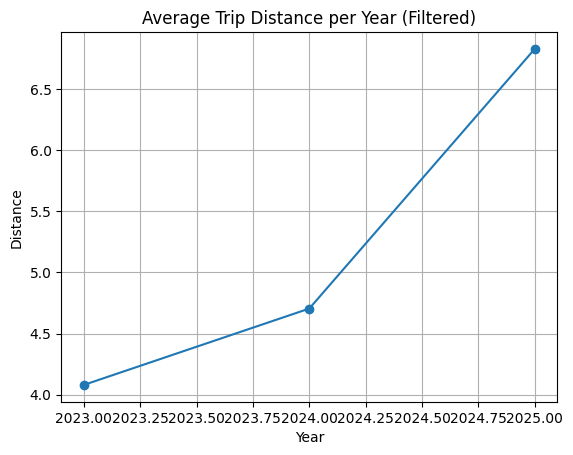

In [ ]:
df_dist = con.execute("""
SELECT
    year,
    AVG(trip_distance) AS avg_distance
FROM trips_filtered
GROUP BY year
ORDER BY year
""").df()

plt.figure()
plt.plot(df_dist["year"], df_dist["avg_distance"], marker="o")
plt.title("Average Trip Distance per Year (in miles)")
plt.xlabel("Year")
plt.ylabel("Distance")
plt.grid()
plt.show()

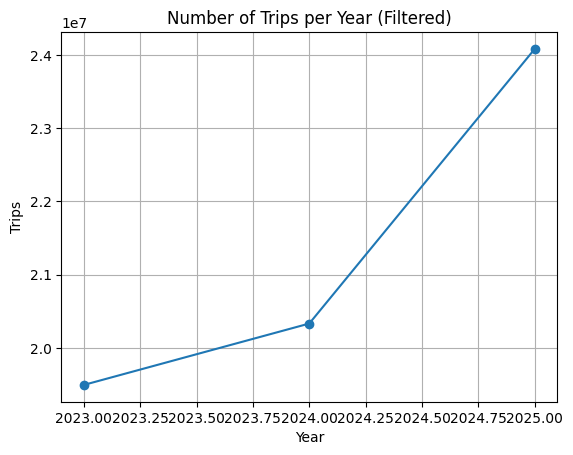

In [ ]:
df_year = con.execute("""
SELECT
    year,
    COUNT(*) AS n_trips
FROM trips_filtered
GROUP BY year
ORDER BY year
""").df()

plt.figure()
plt.plot(df_year["year"], df_year["n_trips"], marker="o")
plt.title("Number of Trips per Year")
plt.xlabel("Year")
plt.ylabel("Trips")
plt.grid()
plt.show()

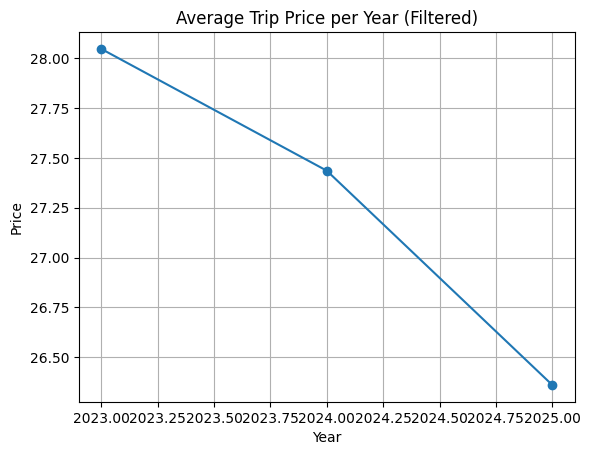

In [ ]:
df_price = con.execute("""
SELECT
    year,
    AVG(total_amount) AS avg_price
FROM trips_filtered
GROUP BY year
ORDER BY year
""").df()

plt.figure()
plt.plot(df_price["year"], df_price["avg_price"], marker="o")
plt.title("Average Trip Price per Year")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid()
plt.show()

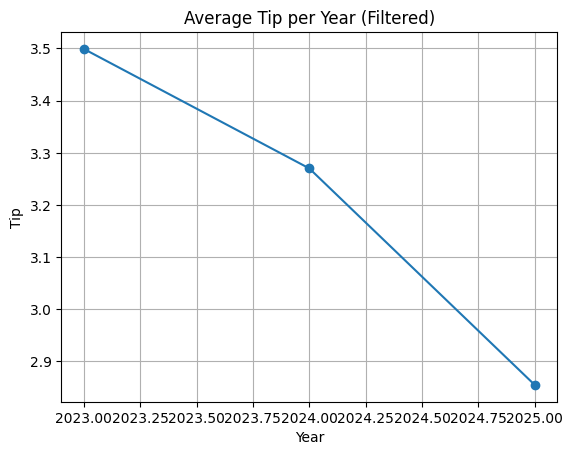

In [ ]:
df_tip = con.execute("""
SELECT
    year,
    AVG(tip_amount) AS avg_tip
FROM trips_filtered
GROUP BY year
ORDER BY year
""").df()

plt.figure()
plt.plot(df_tip["year"], df_tip["avg_tip"], marker="o")
plt.title("Average Tip per Year")
plt.xlabel("Year")
plt.ylabel("Tip")
plt.grid()
plt.show()

In [24]:
# ---------------------------------------------------------
# DATA QUALITY CHECK (missing values, invalid values, outliers)
# ---------------------------------------------------------

import matplotlib.pyplot as plt

cols = ["trip_distance", "fare_amount", "passenger_count"]

print("=== MISSING VALUES (%) ===")
print((result[cols].isna().mean() * 100).round(2))
print()

print("=== BASIC STATS ===")
print(resultf[cols].describe())
print()

print("=== INVALID VALUES (counts) ===")
print("trip_distance <= 0 :", (result["trip_distance"] <= 0).sum())
print("fare_amount <= 0   :", (result["fare_amount"] <= 0).sum())
print("passenger_count <= 0 :", (result["passenger_count"] <= 0).sum())
print()

print("=== OUTLIERS (quantiles) ===")
for col in cols:
    q = result[col].quantile([0.01, 0.5, 0.99])
    print(f"{col}:\n{q}\n")

# ---------------------------------------------------------
# VISUAL CHECKS
# ---------------------------------------------------------
for col in cols:
    plt.figure()
    plt.hist(result[col].dropna(), bins=100)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

    plt.figure()
    plt.boxplot(result[col].dropna(), vert=False)
    plt.title(f"{col} boxplot")
    plt.show()

=== MISSING VALUES (%) ===


TypeError: unhashable type: 'list'